In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('TikTok-datasets.csv')
data.head()



,url,post_url,post_id,post_date_created,date_created,comment_text,num_likes,num_replies,commenter_user_name,commenter_id,commenter_url,comment_id,comment_url
0,https://www.tiktok.com/@dr.jubairsfinance/vide...,https://www.tiktok.com/@dr.jubairsfinance/vide...,7381541963469786401,"""2024-06-17T18:32:51.000Z""","""2024-06-17T20:00:29.000Z""",What is the dividend yield on this fund ?,1,1,fin███ Ai███n,6775842202897449989,https://www.tiktok.com/@finlayaitken6,7381564492096340768,https://www.tiktok.com/@dr.jubairsfinance/vide...
1,https://www.tiktok.com/@dr.jubairsfinance/vide...,https://www.tiktok.com/@dr.jubairsfinance/vide...,7411581429219364128,"""2024-09-06T17:21:28.000Z""","""2024-09-08T10:21:17.000Z""",Too much stress with stocks bro,2,2,kap███ate███19,6825119749132076038,https://www.tiktok.com/@kapilpatel8819,7412215320918655777,https://www.tiktok.com/@dr.jubairsfinance/vide...
2,https://www.tiktok.com/@dr.jubairsfinance/vide...,https://www.tiktok.com/@dr.jubairsfinance/vide...,7411581429219364128,"""2024-09-06T17:21:28.000Z""","""2024-09-08T08:52:47.000Z""","wouldn't really call it a crash , maybe use th...",0,2,Narz,6935516928958579718,https://www.tiktok.com/@narzx97,7412192541975790369,https://www.tiktok.com/@dr.jubairsfinance/vide...
3,https://www.tiktok.com/@dr.jubairsfinance/vide...,https://www.tiktok.com/@dr.jubairsfinance/vide...,7438649135953235232,"""2024-11-18T15:57:56.000Z""","""2024-11-18T16:09:45.000Z""",Delivery hero.. wish I’d put kkkk in that 🤣,1,1,tra███e13███,7056415277432570885,https://www.tiktok.com/@trazeie13,7438652110797849376,https://www.tiktok.com/@dr.jubairsfinance/vide...
4,https://www.tiktok.com/@dr.jubairsfinance/vide...,https://www.tiktok.com/@dr.jubairsfinance/vide...,7400399808696962337,"""2024-08-07T14:10:55.000Z""","""2024-08-07T15:55:35.000Z""","I made $82,000 in 7 days investing in trading ...",0,0,kar███,7389531293161735174,https://www.tiktok.com/@karenj654,7400426764684264198,https://www.tiktok.com/@dr.jubairsfinance/vide...


In [3]:
data["comment_text"].head(10)

0            What is the dividend yield on this fund ?
1                      Too much stress with stocks bro
2    wouldn't really call it a crash , maybe use th...
3          Delivery hero.. wish I’d put kkkk in that 🤣
4    I made $82,000 in 7 days investing in trading ...
5                                    Why not vanguard?
6    investing is longterm. Why do you look at your...
7        do you not end up losing money from the fees?
8    My goal is to make good profits every 24 hours...
9    @OFFICIAL MOVINGCYBER ACCOUNT Es muy perfecto\...
Name: comment_text, dtype: object

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   url                  1000 non-null   object
 1   post_url             1000 non-null   object
 2   post_id              1000 non-null   int64 
 3   post_date_created    1000 non-null   object
 4   date_created         1000 non-null   object
 5   comment_text         1000 non-null   object
 6   num_likes            1000 non-null   int64 
 7   num_replies          1000 non-null   int64 
 8   commenter_user_name  1000 non-null   object
 9   commenter_id         1000 non-null   int64 
 10  commenter_url        1000 non-null   object
 11  comment_id           1000 non-null   int64 
 12  comment_url          1000 non-null   object
dtypes: int64(5), object(8)
memory usage: 101.7+ KB


In [5]:
data.shape

(1000, 13)

In [6]:
# Importer les bibliothèques nécessaires pour l'analyse
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuration pour de meilleurs graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Analyse de la distribution des longueurs de commentaires

Pour décider quelle longueur de texte utiliser (32, 64, ou 128 tokens comme dans SaMIA), analysons la distribution des longueurs.

In [7]:
# Calculer la longueur de chaque commentaire en nombre de mots (tokens)
data['comment_length_words'] = data['comment_text'].astype(str).apply(lambda x: len(x.split()))

# Calculer la longueur en caractères aussi
data['comment_length_chars'] = data['comment_text'].astype(str).apply(len)

# Afficher les statistiques descriptives
print("=== STATISTIQUES DES LONGUEURS DE COMMENTAIRES (en mots) ===")
print(data['comment_length_words'].describe())
print("\n=== STATISTIQUES DES LONGUEURS DE COMMENTAIRES (en caractères) ===")
print(data['comment_length_chars'].describe())

=== STATISTIQUES DES LONGUEURS DE COMMENTAIRES (en mots) ===
count    1000.000000
mean       11.500000
std         9.997497
min         1.000000
25%         4.000000
50%         9.000000
75%        17.000000
max        73.000000
Name: comment_length_words, dtype: float64

=== STATISTIQUES DES LONGUEURS DE COMMENTAIRES (en caractères) ===
count    1000.00000
mean       62.78400
std        51.17572
min         1.00000
25%        25.00000
50%        47.00000
75%        91.00000
max       384.00000
Name: comment_length_chars, dtype: float64


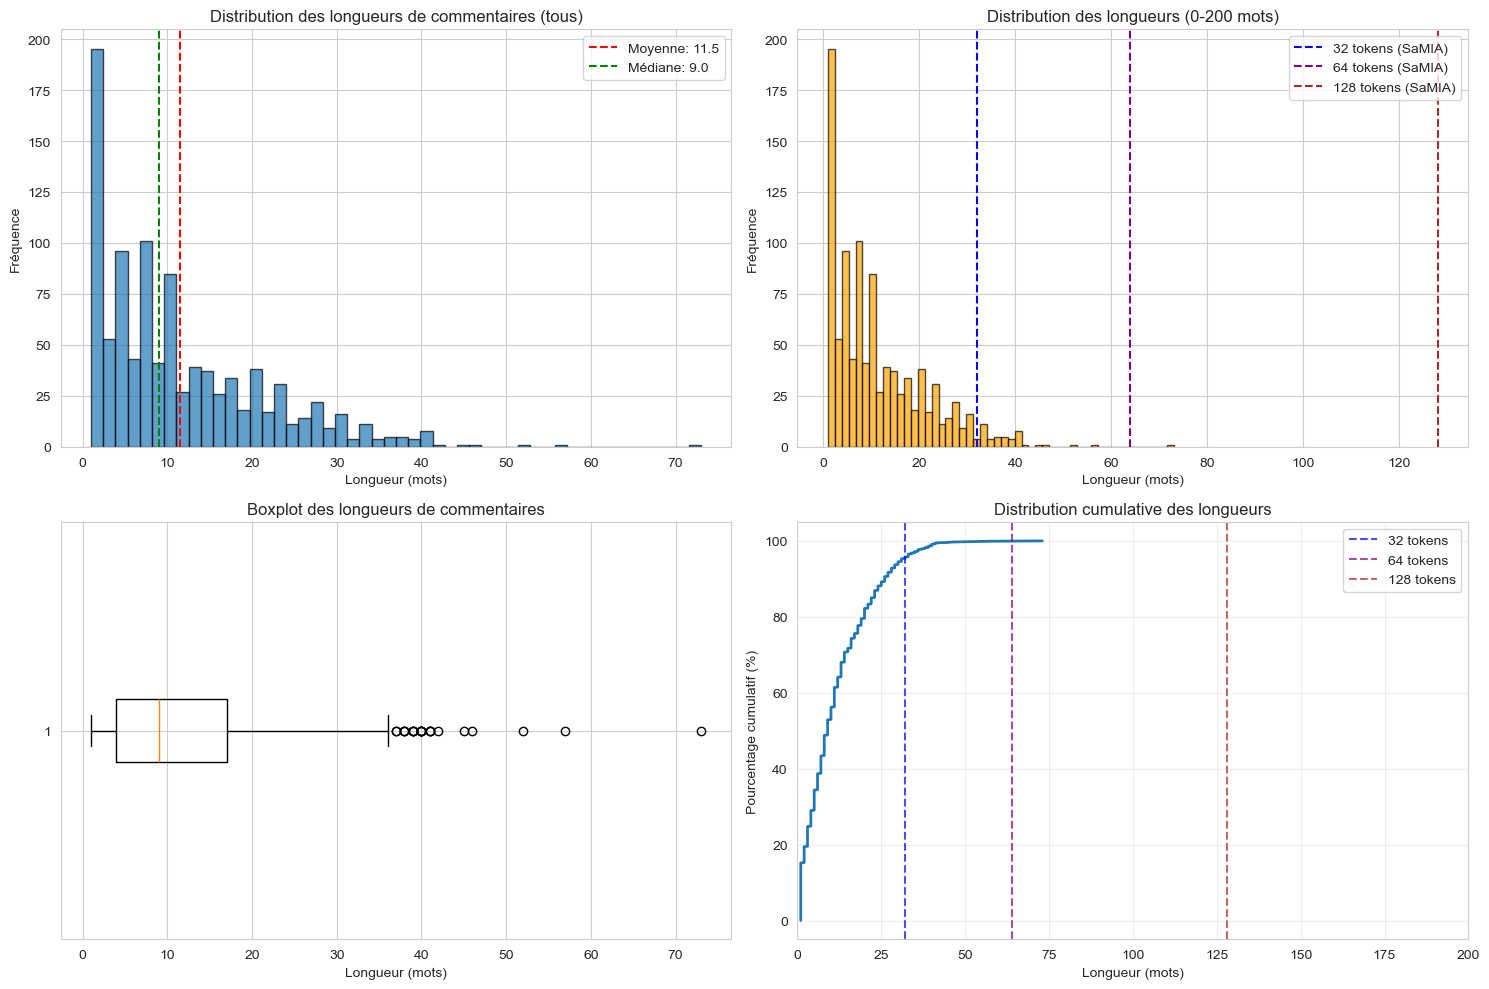

In [8]:
# Visualiser la distribution des longueurs de commentaires
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme de toutes les longueurs
axes[0, 0].hist(data['comment_length_words'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Longueur (mots)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des longueurs de commentaires (tous)')
axes[0, 0].axvline(data['comment_length_words'].mean(), color='red', linestyle='--', label=f'Moyenne: {data["comment_length_words"].mean():.1f}')
axes[0, 0].axvline(data['comment_length_words'].median(), color='green', linestyle='--', label=f'Médiane: {data["comment_length_words"].median():.1f}')
axes[0, 0].legend()

# Histogramme zoomé (0-200 mots)
data_filtered = data[data['comment_length_words'] <= 200]
axes[0, 1].hist(data_filtered['comment_length_words'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Longueur (mots)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution des longueurs (0-200 mots)')
axes[0, 1].axvline(32, color='blue', linestyle='--', label='32 tokens (SaMIA)')
axes[0, 1].axvline(64, color='purple', linestyle='--', label='64 tokens (SaMIA)')
axes[0, 1].axvline(128, color='brown', linestyle='--', label='128 tokens (SaMIA)')
axes[0, 1].legend()

# Boxplot
axes[1, 0].boxplot(data['comment_length_words'], vert=False)
axes[1, 0].set_xlabel('Longueur (mots)')
axes[1, 0].set_title('Boxplot des longueurs de commentaires')

# Distribution cumulative
sorted_lengths = np.sort(data['comment_length_words'])
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
axes[1, 1].plot(sorted_lengths, cumulative, linewidth=2)
axes[1, 1].axvline(32, color='blue', linestyle='--', label='32 tokens', alpha=0.7)
axes[1, 1].axvline(64, color='purple', linestyle='--', label='64 tokens', alpha=0.7)
axes[1, 1].axvline(128, color='brown', linestyle='--', label='128 tokens', alpha=0.7)
axes[1, 1].set_xlabel('Longueur (mots)')
axes[1, 1].set_ylabel('Pourcentage cumulatif (%)')
axes[1, 1].set_title('Distribution cumulative des longueurs')
axes[1, 1].set_xlim(0, 200)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Calculer les pourcentages de commentaires selon les seuils SaMIA
print("=== ANALYSE PAR RAPPORT AUX SEUILS SaMIA ===\n")

thresholds = [32, 64, 128]
for threshold in thresholds:
    count_below = (data['comment_length_words'] < threshold).sum()
    count_above = (data['comment_length_words'] >= threshold).sum()
    pct_below = (count_below / len(data)) * 100
    pct_above = (count_above / len(data)) * 100
    
    print(f"Seuil: {threshold} mots")
    print(f"  - Commentaires < {threshold} mots: {count_below} ({pct_below:.1f}%)")
    print(f"  - Commentaires >= {threshold} mots: {count_above} ({pct_above:.1f}%)")
    print()

# Afficher aussi les quartiles
print("\n=== QUARTILES ===")
print(f"10% des commentaires ont <= {data['comment_length_words'].quantile(0.1):.0f} mots")
print(f"25% des commentaires ont <= {data['comment_length_words'].quantile(0.25):.0f} mots")
print(f"50% des commentaires ont <= {data['comment_length_words'].quantile(0.50):.0f} mots (médiane)")
print(f"75% des commentaires ont <= {data['comment_length_words'].quantile(0.75):.0f} mots")
print(f"90% des commentaires ont <= {data['comment_length_words'].quantile(0.90):.0f} mots")

=== ANALYSE PAR RAPPORT AUX SEUILS SaMIA ===

Seuil: 32 mots
  - Commentaires < 32 mots: 953 (95.3%)
  - Commentaires >= 32 mots: 47 (4.7%)

Seuil: 64 mots
  - Commentaires < 64 mots: 999 (99.9%)
  - Commentaires >= 64 mots: 1 (0.1%)

Seuil: 128 mots
  - Commentaires < 128 mots: 1000 (100.0%)
  - Commentaires >= 128 mots: 0 (0.0%)


=== QUARTILES ===
10% des commentaires ont <= 1 mots
25% des commentaires ont <= 4 mots
50% des commentaires ont <= 9 mots (médiane)
75% des commentaires ont <= 17 mots
90% des commentaires ont <= 26 mots
